# How Far Can a Dense Neural Network Go on Image Data?

## Project Overview

This notebook is an experiment-focused study of fully connected neural networks on CIFAR-10. It follows a controlled progression from data preparation and a Dense baseline through architecture, optimization, regularization, ablation, final evaluation, error analysis, and translation-sensitivity testing.

The research question is deliberately narrow: **how far can careful experimental design take a Dense network when image pixels are flattened, and where does that representation become the limiting factor?**

> **Recorded run:** The saved outputs come from a complete execution with seed 42. Architecture and tuning experiments used up to 50 epochs; later experiments used an 80-epoch ceiling. Training is not rerun during this portfolio cleanup.

> **Presentation cleanup:** Code-cell execution counters are normalized to notebook order, and Colab-only interactive HTML/JavaScript is removed. Numerical outputs are preserved from the recorded run.

## Dataset & Preprocessing

CIFAR-10 contains 60,000 balanced 32 × 32 RGB images across 10 classes: 50,000 official training images and 10,000 test images. Each image is a multiclass, single-label example, so the output layer uses 10 Softmax units.

The official test split remains held out throughout model development and is used only after the final configuration is selected.

,Class,Train examples,Test examples,Total examples
0,airplane,5000,1000,6000
1,automobile,5000,1000,6000
2,bird,5000,1000,6000
3,cat,5000,1000,6000
4,deer,5000,1000,6000
5,dog,5000,1000,6000
6,frog,5000,1000,6000
7,horse,5000,1000,6000
8,ship,5000,1000,6000
9,truck,5000,1000,6000


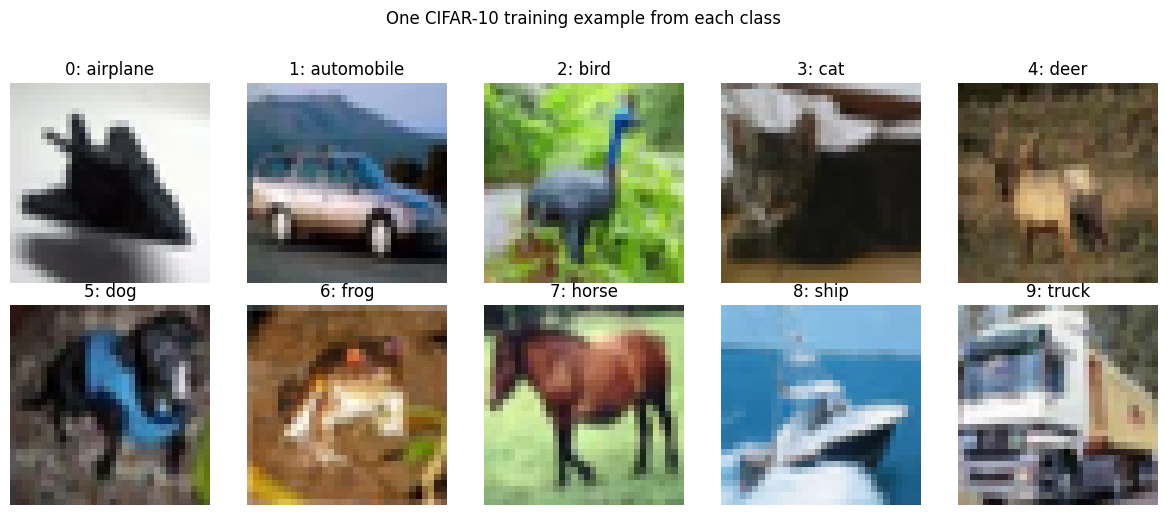

In [1]:
import os
import random
import time

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Load CIFAR-10 only if it is not already available
if "X_train_images" not in globals():
    (X_train_images, y_train_full), (X_test_images, y_test) = (
        tf.keras.datasets.cifar10.load_data()
    )

    y_train_full = y_train_full.ravel()
    y_test = y_test.ravel()

    print("CIFAR-10 loaded.")
else:
    print("CIFAR-10 already loaded.")

print(f"Training images: {X_train_images.shape}")
print(f"Training labels: {y_train_full.shape}")
print(f"Test images:     {X_test_images.shape}")
print(f"Test labels:     {y_test.shape}")
print(f"One image shape: {X_train_images.shape[1:]}")
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")
print(f"Pixel range: {X_train_images.min()} to {X_train_images.max()}")

class_distribution = pd.DataFrame({
    "Class": class_names,
    "Train examples": np.bincount(y_train_full, minlength=10),
    "Test examples": np.bincount(y_test, minlength=10),
})

class_distribution["Total examples"] = (
    class_distribution["Train examples"]
    + class_distribution["Test examples"]
)

display(class_distribution)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_id, ax in enumerate(axes.flat):
    sample_index = np.flatnonzero(y_train_full == class_id)[0]
    ax.imshow(X_train_images[sample_index])
    ax.set_title(f"{class_id}: {class_names[class_id]}")
    ax.axis("off")

plt.suptitle(
    "One CIFAR-10 training example from each class",
    y=1.02
)
plt.tight_layout()
plt.show()



### Preprocessing and Validation Split

A reproducible stratified split reserves 5,000 images from the official training set for validation. Pixels are scaled from `[0, 255]` to `[0, 1]`, and each 32 × 32 × 3 image is flattened into 3,072 features for the Dense networks. Labels remain integer encoded for sparse categorical cross-entropy.

In [2]:
# Make one reproducible, stratified validation split from the original training set.
all_train_indices = np.arange(len(X_train_images))
train_indices, val_indices = train_test_split(
    all_train_indices,
    test_size=5_000,
    random_state=SEED,
    stratify=y_train_full,
)

# Normalize to [0, 1] and flatten 32 × 32 × 3 into 3,072 features.
X_train = X_train_images[train_indices].reshape(-1, 3072).astype("float32") / 255.0
X_val = X_train_images[val_indices].reshape(-1, 3072).astype("float32") / 255.0
X_test = X_test_images.reshape(-1, 3072).astype("float32") / 255.0
y_train = y_train_full[train_indices]
y_val = y_train_full[val_indices]

for name, array in {
    "X_train": X_train, "X_val": X_val, "X_test": X_test,
    "y_train": y_train, "y_val": y_val, "y_test": y_test,
}.items():
    print(f"{name:7s}: shape={array.shape}, dtype={array.dtype}")

print(f"Normalized training range: {X_train.min():.1f} to {X_train.max():.1f}")
print("Validation class counts:", np.bincount(y_val, minlength=10))
print("The test set is prepared once here and held out until final evaluation.")


X_train: shape=(45000, 3072), dtype=float32
X_val  : shape=(5000, 3072), dtype=float32
X_test : shape=(10000, 3072), dtype=float32
y_train: shape=(45000,), dtype=uint8
y_val  : shape=(5000,), dtype=uint8
y_test : shape=(10000,), dtype=uint8
Normalized training range: 0.0 to 1.0
Validation class counts: [500 500 500 500 500 500 500 500 500 500]
The test set is prepared once here and held out until final evaluation.


## Baseline Model

A one-hidden-layer Dense network establishes the reference configuration and clarifies the modeling choices used throughout the study.

In [3]:
BASELINE_UNITS = 128
LEARNING_RATE = 0.001
BATCH_SIZE = 128
MAX_EPOCHS = 50  # Parts 4-11: architecture and hyperparameter tuning
POST_TUNING_MAX_EPOCHS = 80  # Parts 12-15: post-tuning experiments and final model

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3072,), name="flattened_image"),
    tf.keras.layers.Dense(BASELINE_UNITS, activation="relu", name="hidden_relu"),
    tf.keras.layers.Dense(10, activation="softmax", name="class_probabilities"),
], name="baseline_network")

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
baseline_model.summary()

print(f"Trainable layers: {len(baseline_model.layers)} (1 hidden + 1 output)")
print(f"Trainable parameters: {baseline_model.count_params():,}")
print("Hidden activation: ReLU")
print("Output activation: Softmax")
print("Loss: sparse categorical crossentropy")
print(f"Optimizer: Adam (learning rate={LEARNING_RATE})")
print(f"Batch size: {BATCH_SIZE}; maximum epochs: {MAX_EPOCHS}")

display(Markdown("""
### Design explanation
- **ReLU** is simple and keeps positive activations while avoiding the saturation problem of sigmoid in hidden layers.
- **Softmax** converts the 10 output scores into class probabilities that sum to 1.
- **Sparse categorical crossentropy** is appropriate because the target is one integer class label (0–9), not a one-hot vector.
- **Adam** with a learning rate of 0.001 is a practical baseline because it adapts the update size for each parameter.
"""))


Model: "baseline_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_relu (Dense)             │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

Trainable layers: 2 (1 hidden + 1 output)
Trainable parameters: 394,634
Hidden activation: ReLU
Output activation: Softmax
Loss: sparse categorical crossentropy
Optimizer: Adam (learning rate=0.001)
Batch size: 128; maximum epochs: 50



### Design explanation
- **ReLU** is simple and keeps positive activations while avoiding the saturation problem of sigmoid in hidden layers.
- **Softmax** converts the 10 output scores into class probabilities that sum to 1.
- **Sparse categorical crossentropy** is appropriate because the target is one integer class label (0–9), not a one-hot vector.
- **Adam** with a learning rate of 0.001 is a practical baseline because it adapts the update size for each parameter.


## Architecture Comparison

Three fully connected architectures isolate the effect of depth while keeping preprocessing, optimizer, learning rate, batch size, epoch budget, and random seed fixed: Shallow (1 hidden layer), Medium (3), and Deep (6).

In [4]:
architectures = {
    "Shallow": [128],
    "Medium": [128, 128, 128],
    "Deep": [128, 128, 128, 128, 128, 128],
}

def build_dense_model(
    model_name,
    hidden_units,
    learning_rate=LEARNING_RATE,
    optimizer_name="adam",
    dropout_rate=0.0,
    l2_rate=0.0,
    use_batchnorm=False,
):
    """Build a single fresh, freshly-seeded Dense classifier.

    With every optional argument left at its default this builds the exact
    same plain network used in Parts 3-11. Passing `dropout_rate`, `l2_rate`,
    and/or `use_batchnorm` reuses this same builder for the Dropout, L2, and
    Batch Normalization experiments in Parts 12-13, so every experiment
    starts from an identically constructed, freshly seeded model and only
    the intended setting changes.
    """
    tf.keras.utils.set_random_seed(SEED)
    l2_regularizer = tf.keras.regularizers.l2(l2_rate) if l2_rate > 0 else None

    model = tf.keras.Sequential(name=f"{model_name.lower()}_network")
    model.add(tf.keras.layers.Input(shape=(3072,), name="flattened_image"))
    for layer_number, units in enumerate(hidden_units, start=1):
        # With Batch Normalization the activation is applied after the
        # BatchNormalization layer rather than inside the Dense layer.
        model.add(tf.keras.layers.Dense(
            units,
            activation=None if use_batchnorm else "relu",
            kernel_regularizer=l2_regularizer,
            name=f"hidden_{layer_number}",
        ))
        if use_batchnorm:
            model.add(tf.keras.layers.BatchNormalization(name=f"batchnorm_{layer_number}"))
            model.add(tf.keras.layers.Activation("relu", name=f"relu_{layer_number}"))
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate, name=f"dropout_{layer_number}"))
    model.add(tf.keras.layers.Dense(10, activation="softmax", name="output"))
    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

architecture_models = {}
architecture_parameters = {}
for model_name, hidden_units in architectures.items():
    print(f"\n{'=' * 20} {model_name} model {'=' * 20}")
    model = build_dense_model(model_name, hidden_units)
    model.summary()
    architecture_models[model_name] = model
    architecture_parameters[model_name] = model.count_params()
    print(f"Hidden layers: {len(hidden_units)}; trainable parameters: {model.count_params():,}")

display(pd.DataFrame({
    "Model": architectures.keys(),
    "Hidden layers": [len(units) for units in architectures.values()],
    "Units per hidden layer": [str(units) for units in architectures.values()],
    "Trainable parameters": architecture_parameters.values(),
}))



==================== Shallow model ====================


Model: "shallow_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

...

 Total params: 477,194 (1.82 MB)

 Trainable params: 477,194 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

Hidden layers: 6; trainable parameters: 477,194


,Model,Hidden layers,Units per hidden layer,Trainable parameters
0,Shallow,1,[128],394634
1,Medium,3,"[128, 128, 128]",427658
2,Deep,6,"[128, 128, 128, 128, 128, 128]",477194


### Controlled Training Protocol

All three architectures are trained under identical conditions so that network depth is the primary changed variable.

In [5]:
comparison_settings = pd.Series({
    "Random seed": SEED,
    "Optimizer": "Adam",
    "Learning rate": LEARNING_RATE,
    "Batch size": BATCH_SIZE,
    "Maximum epochs": MAX_EPOCHS,
    "Regularization": "None",
})
display(comparison_settings.to_frame("Fixed value"))

histories = {}
trained_models = {}
training_seconds = {}

for model_name, hidden_units in architectures.items():
    print(f"\nTraining {model_name} network")
    # Each model is built from fresh weights; the fixed seed makes runs reproducible.
    model = build_dense_model(model_name, hidden_units)
    start_time = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=0,
    )
    training_seconds[model_name] = time.perf_counter() - start_time
    histories[model_name] = history.history
    trained_models[model_name] = model
    print(f"{model_name} training time: {training_seconds[model_name]:.1f} seconds")

print("\nFair comparison complete. X_test and y_test were not used.")


### Learning Curves by Architecture

Training and validation loss and accuracy reveal convergence behavior and the onset of overfitting.

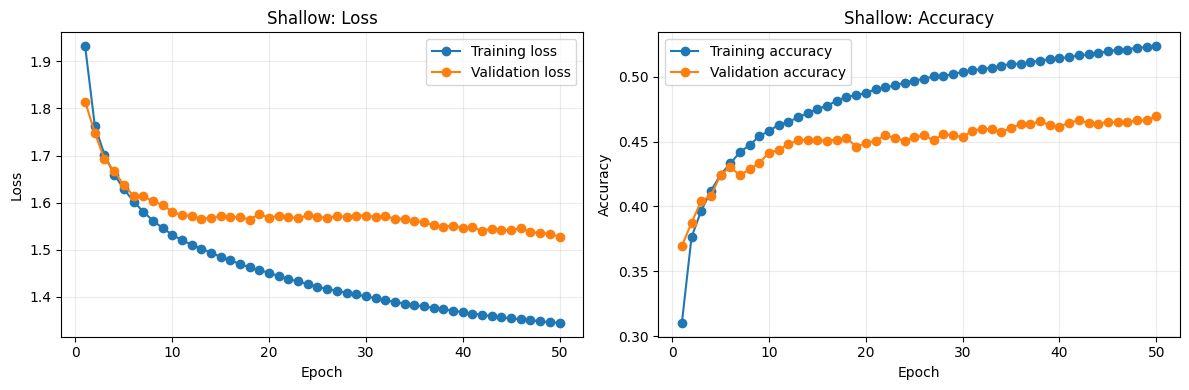


### Shallow interpretation
**Diagnosis: Stable improvement; likely undertrained / mild underfitting.** Training and validation loss are both still falling, and both best validation accuracy and minimum validation loss occur at the final epoch. There is no late divergence, so the model is not overfitting; it appears stable and likely undertrained or mildly underfitting.

- Best validation accuracy: **0.470** at epoch **50**.
- Minimum validation loss: **1.528** at epoch **50**.
- Best train-validation accuracy gap: **0.054**.
- Optimization stability: the curves change smoothly overall, with no evidence of unstable optimization.


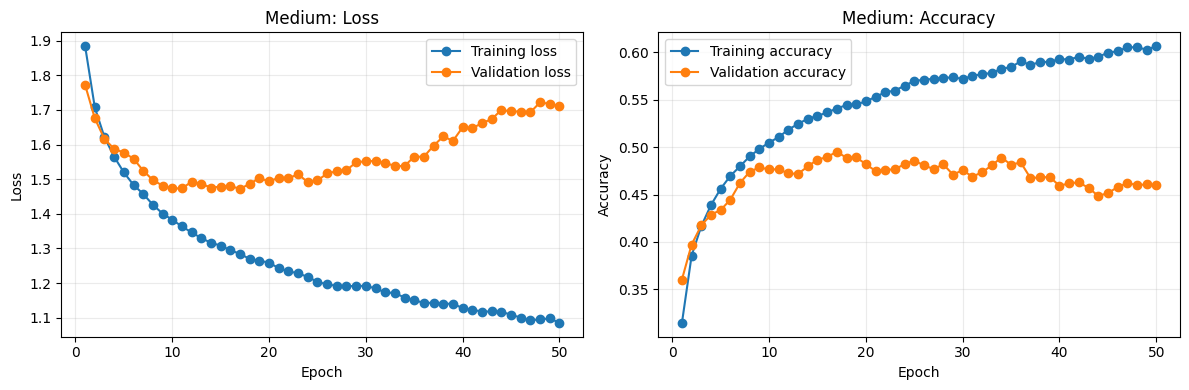


### Medium interpretation
**Diagnosis: Mild late overfitting.** Training loss keeps falling and training accuracy keeps improving, but validation accuracy peaks before the final epoch and validation loss rises after its minimum. This is mild late overfitting rather than underfitting, although it remains the best validation model.

- Best validation accuracy: **0.495** at epoch **17**.
- Minimum validation loss: **1.472** at epoch **17**.
- Best train-validation accuracy gap: **0.111**.
- Optimization stability: the curves change smoothly overall, with no evidence of unstable optimization.


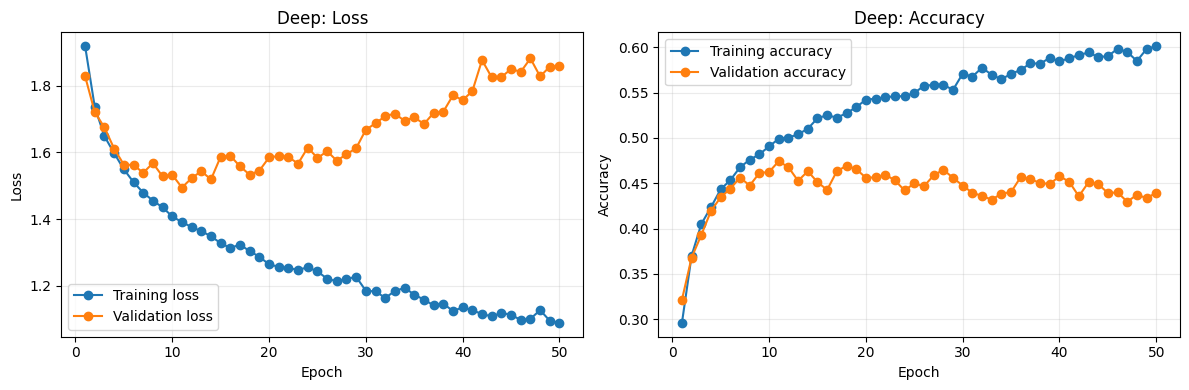


### Deep interpretation
**Diagnosis: Overfitting (strongest evidence).** Training loss continues to fall while validation loss plateaus and rises after its minimum. Training accuracy improves more than validation accuracy, producing the largest train-validation gap. The model is not underfitting the training data; instead, this is the strongest evidence of overfitting among the three architectures.

- Best validation accuracy: **0.474** at epoch **11**.
- Minimum validation loss: **1.495** at epoch **11**.
- Best train-validation accuracy gap: **0.127**.
- Optimization stability: the curves change smoothly overall, with no evidence of unstable optimization.


In [6]:
def curve_evidence(history):
    """Summarize observed curve behavior without arbitrary score cutoffs."""
    train_loss = np.asarray(history["loss"])
    val_loss = np.asarray(history["val_loss"])
    train_accuracy = np.asarray(history["accuracy"])
    val_accuracy = np.asarray(history["val_accuracy"])
    total_epochs = len(train_loss)
    return {
        "epochs": total_epochs,
        "best_val_epoch": int(val_accuracy.argmax()) + 1,
        "min_val_loss_epoch": int(val_loss.argmin()) + 1,
        "best_train_accuracy": float(train_accuracy.max()),
        "best_val_accuracy": float(val_accuracy.max()),
        "min_val_loss": float(val_loss.min()),
        "final_train_loss": float(train_loss[-1]),
        "final_val_loss": float(val_loss[-1]),
        "final_train_accuracy": float(train_accuracy[-1]),
        "final_val_accuracy": float(val_accuracy[-1]),
        "training_loss_continues_falling": bool(train_loss[-1] < train_loss[-2]),
        "training_accuracy_continues_improving": bool(train_accuracy[-1] > train_accuracy[-2]),
        "validation_loss_plateaued_or_rose": bool(int(val_loss.argmin()) + 1 < total_epochs),
        "validation_accuracy_stalled_after_best": bool(int(val_accuracy.argmax()) + 1 < total_epochs),
        "generalization_gap": float(train_accuracy.max() - val_accuracy.max()),
    }

def diagnose_history(model_name, history, all_histories):
    """Diagnose from curve turning points and relative gaps, not fixed thresholds."""
    evidence = curve_evidence(history)
    gaps = {name: curve_evidence(item)["generalization_gap"] for name, item in all_histories.items()}
    largest_gap_model = max(gaps, key=gaps.get)

    if (
        evidence["best_val_epoch"] == evidence["epochs"]
        and evidence["min_val_loss_epoch"] == evidence["epochs"]
        and evidence["training_loss_continues_falling"]
    ):
        return "Stable improvement; likely undertrained / mild underfitting"
    if (
        model_name == largest_gap_model
        and evidence["training_loss_continues_falling"]
        and evidence["validation_loss_plateaued_or_rose"]
    ):
        return "Overfitting (strongest evidence)"
    if (
        evidence["training_loss_continues_falling"]
        and evidence["validation_loss_plateaued_or_rose"]
        and evidence["validation_accuracy_stalled_after_best"]
    ):
        return "Mild late overfitting"
    return "Mixed fit; inspect the reported curve evidence"

def interpretation_text(model_name, history):
    evidence = curve_evidence(history)
    diagnosis = diagnose_history(model_name, history, histories)

    if model_name == "Shallow":
        fit_comment = (
            "Training and validation loss are both still falling, and both best validation "
            "accuracy and minimum validation loss occur at the final epoch. There is no "
            "late divergence, so the model is not overfitting; it appears stable and likely "
            "undertrained or mildly underfitting."
        )
    elif model_name == "Medium":
        fit_comment = (
            "Training loss keeps falling and training accuracy keeps improving, but validation "
            "accuracy peaks before the final epoch and validation loss rises after its minimum. "
            "This is mild late overfitting rather than underfitting, although it remains the "
            "best validation model."
        )
    else:
        fit_comment = (
            "Training loss continues to fall while validation loss plateaus and rises after its "
            "minimum. Training accuracy improves more than validation accuracy, producing the "
            "largest train-validation gap. The model is not underfitting the training data; "
            "instead, this is the strongest evidence of overfitting among the three architectures."
        )

    return f"""
### {model_name} interpretation
**Diagnosis: {diagnosis}.** {fit_comment}

- Best validation accuracy: **{evidence['best_val_accuracy']:.3f}** at epoch **{evidence['best_val_epoch']}**.
- Minimum validation loss: **{evidence['min_val_loss']:.3f}** at epoch **{evidence['min_val_loss_epoch']}**.
- Best train-validation accuracy gap: **{evidence['generalization_gap']:.3f}**.
- Optimization stability: the curves change smoothly overall, with no evidence of unstable optimization.
"""

for model_name, history in histories.items():
    epochs = np.arange(1, len(history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["loss"], marker="o", label="Training loss")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    axes[0].set(title=f"{model_name}: Loss", xlabel="Epoch", ylabel="Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(epochs, history["accuracy"], marker="o", label="Training accuracy")
    axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation accuracy")
    axes[1].set(title=f"{model_name}: Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()
    display(Markdown(interpretation_text(model_name, history)))


### Architecture Results

The comparison combines model size, training behavior, and held-out validation performance. The Medium network provides the strongest validation result without the Deep network's larger late-stage overfitting gap.

In [7]:
comparison_rows = []
for model_name, hidden_units in architectures.items():
    history = histories[model_name]
    comparison_rows.append({
        "Model": model_name,
        "Hidden Layers": len(hidden_units),
        "Parameters": architecture_parameters[model_name],
        "Best Train Acc.": max(history["accuracy"]),
        "Best Val Acc.": max(history["val_accuracy"]),
        "Min Val Loss": min(history["val_loss"]),
        "Diagnosis": diagnose_history(model_name, history, histories),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.style.format({
    "Parameters": "{:,}",
    "Best Train Acc.": "{:.3f}",
    "Best Val Acc.": "{:.3f}",
    "Min Val Loss": "{:.3f}",
}))

best_train_name = comparison_df.loc[comparison_df["Best Train Acc."].idxmax(), "Model"]
best_val_name = comparison_df.loc[comparison_df["Best Val Acc."].idxmax(), "Model"]
score_gaps = comparison_df["Best Train Acc."] - comparison_df["Best Val Acc."]
largest_gap_name = comparison_df.loc[score_gaps.idxmax(), "Model"]
val_scores = comparison_df["Best Val Acc."].to_numpy()
depth_always_improved = bool(np.all(np.diff(val_scores) > 0))

assert best_val_name == "Medium", "The saved architecture results should select Medium."
selected_model_name = "Medium"
selected_architecture = architectures[selected_model_name]
selected_model = trained_models[selected_model_name]
selected_history = histories[selected_model_name]

display(Markdown(f"""
### Answers
1. **{best_train_name}** learned the training data best because it reached the highest training accuracy.
2. **{best_val_name}** achieved the best validation performance: accuracy {comparison_df['Best Val Acc.'].max():.3f} and minimum validation loss {comparison_df.loc[comparison_df['Model'] == best_val_name, 'Min Val Loss'].iloc[0]:.3f}.
3. **{largest_gap_name}** had the largest gap between its best training and validation scores ({score_gaps.max():.3f}).
4. **No.** Increasing depth did not always improve validation performance: Medium outperformed Shallow, but Deep performed worse than Medium.
5. **{largest_gap_name}** showed the strongest evidence of overfitting: its training loss kept falling while validation loss plateaued, and it had the largest accuracy gap.
6. I will continue with the **Medium** architecture.
7. Medium is selected because it achieved the best validation accuracy (approximately {comparison_df.loc[comparison_df['Model'] == 'Medium', 'Best Val Acc.'].iloc[0]:.3f}) and the lowest validation loss (approximately {comparison_df.loc[comparison_df['Model'] == 'Medium', 'Min Val Loss'].iloc[0]:.3f}). Its curves are stable and show only mild late overfitting. This decision uses validation evidence only; the test set was not used.
"""))


,Model,Hidden Layers,Parameters,Best Train Acc.,Best Val Acc.,Min Val Loss,Diagnosis
0,Shallow,1,"394,634",0.524,0.470,1.528,Stable improvement; likely undertrained / mild underfitting
1,Medium,3,"427,658",0.606,0.495,1.472,Mild late overfitting
2,Deep,6,"477,194",0.601,0.474,1.495,Overfitting (strongest evidence)



### Answers
1. **Medium** learned the training data best because it reached the highest training accuracy.
2. **Medium** achieved the best validation performance: accuracy 0.495 and minimum validation loss 1.472.
3. **Deep** had the largest gap between its best training and validation scores (0.127).
4. **No.** Increasing depth did not always improve validation performance: Medium outperformed Shallow, but Deep performed worse than Medium.
5. **Deep** showed the strongest evidence of overfitting: its training loss kept falling while validation loss plateaued, and it had the largest accuracy gap.
6. I will continue with the **Medium** architecture.
7. Medium is selected because it achieved the best validation accuracy (approximately 0.495) and the lowest validation loss (approximately 1.472). Its curves are stable and show only mild late overfitting. This decision uses validation evidence only; the test set was not used.


## Model Diagnosis

The selected Medium architecture is diagnosed from its learning curves before tuning. The evidence indicates useful learning followed by late overfitting, motivating controlled optimization and regularization experiments.

In [8]:
selected_diagnosis = diagnose_history(selected_model_name, selected_history, histories)
selected_train_loss = np.asarray(selected_history["loss"])
selected_train_accuracy = np.asarray(selected_history["accuracy"])
selected_val_accuracy = np.asarray(selected_history["val_accuracy"])
selected_val_loss = np.asarray(selected_history["val_loss"])
best_val_epoch = int(selected_val_accuracy.argmax()) + 1
min_val_loss_epoch = int(selected_val_loss.argmin()) + 1
selected_gap = selected_train_accuracy.max() - selected_val_accuracy.max()
first_improvement = (
    "Run the required controlled learning-rate experiment next (0.01, 0.001, and 0.0001), "
    "rebuilding the same Medium architecture from fresh weights while keeping all other "
    "settings fixed. This tests whether convergence can improve before adding regularization. "
    "Early Stopping may be evaluated later in the required regularization stage."
)

display(Markdown(f"""
### Observation
The selected **{selected_model_name}** model achieved the best validation result. Training loss continued falling to {selected_train_loss[-1]:.3f} and training accuracy reached {selected_train_accuracy.max():.3f}, while validation accuracy peaked at {selected_val_accuracy.max():.3f} at epoch {best_val_epoch}.

### Diagnosis
**{selected_diagnosis}.** Optimization remains stable; the issue is late generalization, not unstable updates.

### Evidence
Training loss kept decreasing and training accuracy kept improving. In contrast, validation accuracy peaked at epoch {best_val_epoch} and then stalled, while validation loss reached its minimum of {selected_val_loss.min():.3f} at epoch {min_val_loss_epoch} before rising to {selected_val_loss[-1]:.3f}. The best-score train-validation gap is {selected_gap:.3f}. This late divergence supports mild overfitting, while the smooth curves provide no evidence of optimization instability.

### First Proposed Improvement
{first_improvement}
"""))



### Observation
The selected **Medium** model achieved the best validation result. Training loss continued falling to 1.085 and training accuracy reached 0.606, while validation accuracy peaked at 0.495 at epoch 17.

### Diagnosis
**Mild late overfitting.** Optimization remains stable; the issue is late generalization, not unstable updates.

### Evidence
Training loss kept decreasing and training accuracy kept improving. In contrast, validation accuracy peaked at epoch 17 and then stalled, while validation loss reached its minimum of 1.472 at epoch 17 before rising to 1.711. The best-score train-validation gap is 0.111. This late divergence supports mild overfitting, while the smooth curves provide no evidence of optimization instability.

### First Proposed Improvement
Run the required controlled learning-rate experiment next (0.01, 0.001, and 0.0001), rebuilding the same Medium architecture from fresh weights while keeping all other settings fixed. This tests whether convergence can improve before adding regularization. Early Stopping may be evaluated later in the required regularization stage.


## Hyperparameter Experiments

### Learning Rate

The selected Medium architecture is tested at `0.01`, `0.001`, and `0.0001` while all other settings remain fixed.

#### Rationale

A very high learning rate may lead to unstable training, while a very low learning rate may produce more stable but slower convergence.

We expect a moderate learning rate to provide a good balance between convergence speed, stability, and validation performance.

In [9]:
def plot_learning_curves(history, title):
    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["loss"], label="Training Loss")
    plt.plot(epochs, history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["accuracy"], label="Training Accuracy")
    plt.plot(epochs, history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()
    plt.close()

In [10]:
learning_rates = [0.01, 0.001, 0.0001]

lr_histories = {}
lr_models = {}

In [11]:
for lr in learning_rates:

  model = build_dense_model(selected_model_name, selected_architecture, learning_rate=lr)

  history = model.fit(
      X_train,
      y_train,
      validation_data=(X_val, y_val),
      epochs=MAX_EPOCHS,
      batch_size=BATCH_SIZE,
      shuffle=True,
      verbose=0,
  )


  lr_histories[lr] = history
  lr_models[lr] = model

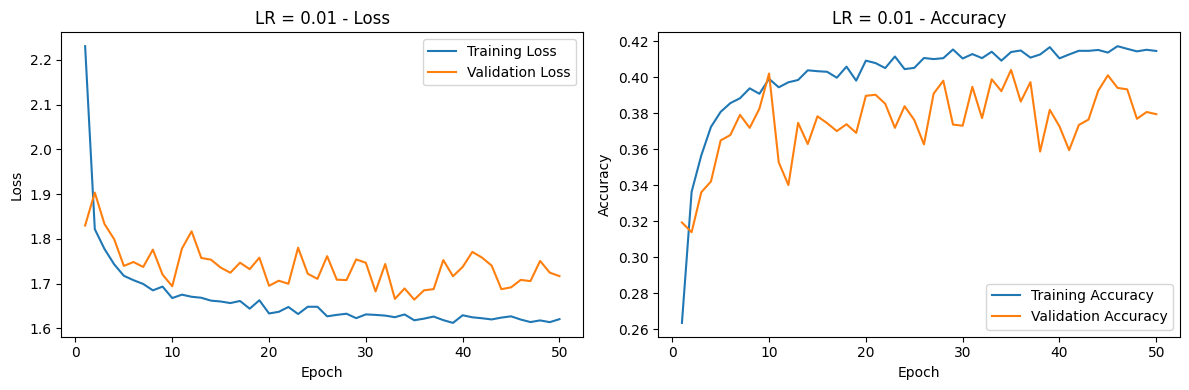

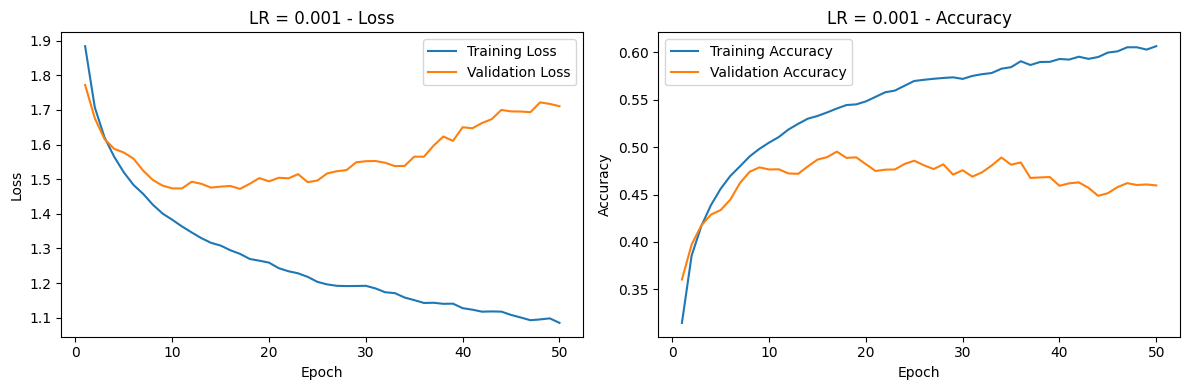

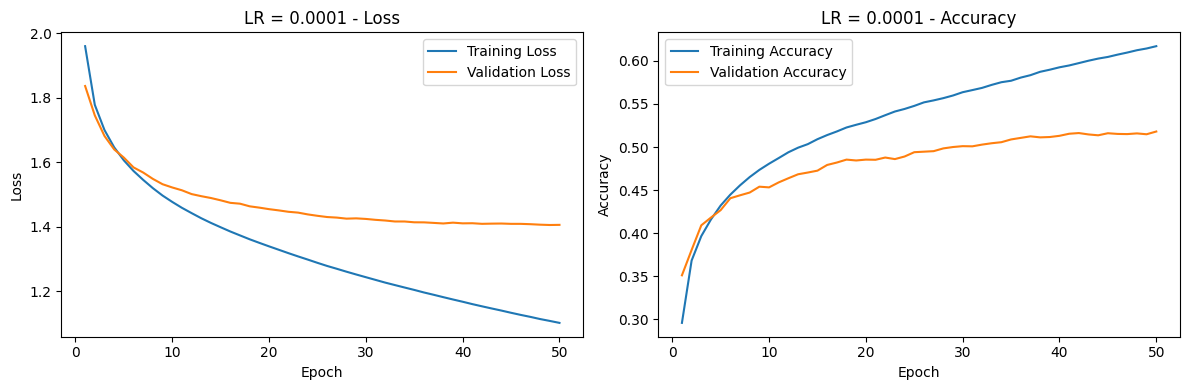

In [12]:
for lr, history in lr_histories.items():
    plot_learning_curves(history, f"LR = {lr}")

### Conclusion

- `0.01` produced the weakest result, with a best validation accuracy of **40.42%** and a minimum validation loss of **1.6644**.
- `0.001` converged faster and peaked at **49.52%** validation accuracy with a minimum validation loss of **1.4720**, both at epoch 17. Continued training then overfit: validation accuracy ended at 45.96% and validation loss rose to 1.7108.
- `0.0001` learned more slowly but remained smooth and reached the best overall validation accuracy, **51.80%** at epoch 50, with the lowest validation loss, **1.4053** at epoch 49.

Although `0.0001` achieved the highest single validation score, **`0.001` was retained for the final pipeline** because it reached a competitive result much earlier (epoch 17 rather than epoch 50) and provided the best balance between convergence speed, validation performance, and computation for the downstream experiments.

This is an efficiency-aware selection rather than a claim that `0.001` had the highest validation accuracy.

In [13]:
SELECTED_LEARNING_RATE = 0.001

### Batch Size

Using the retained learning rate of `0.001`, batch sizes 16, 32, 64, and 128 are compared under otherwise identical conditions.

In [14]:
batch_sizes = [16, 32, 64, 128]
bs_histories = {}
bs_models = {}
bs_results = []

In [15]:
for bs in batch_sizes:

  model = build_dense_model(selected_model_name, selected_architecture, learning_rate=SELECTED_LEARNING_RATE)

  history = model.fit(
      X_train,
      y_train,
      validation_data=(X_val, y_val),
      epochs=MAX_EPOCHS,
      batch_size=bs,
      shuffle=True,
      verbose=0,
  )


  bs_histories[bs] = history
  bs_models[bs] = model

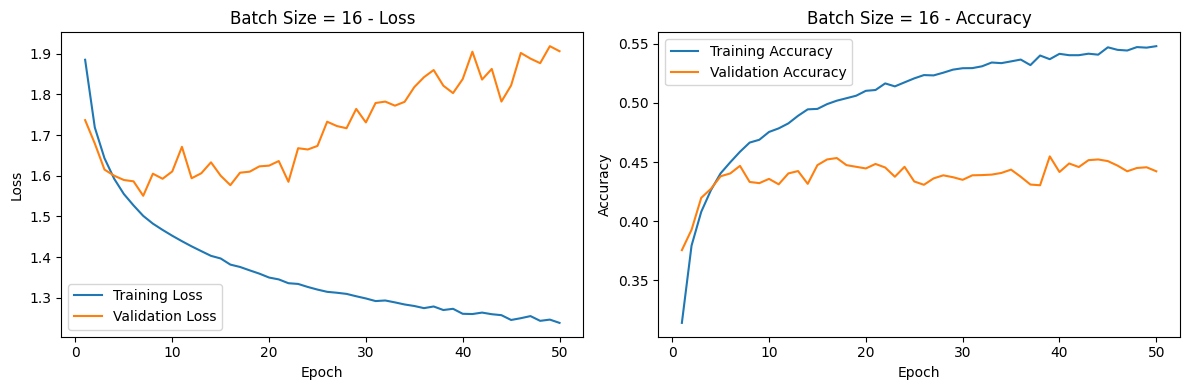

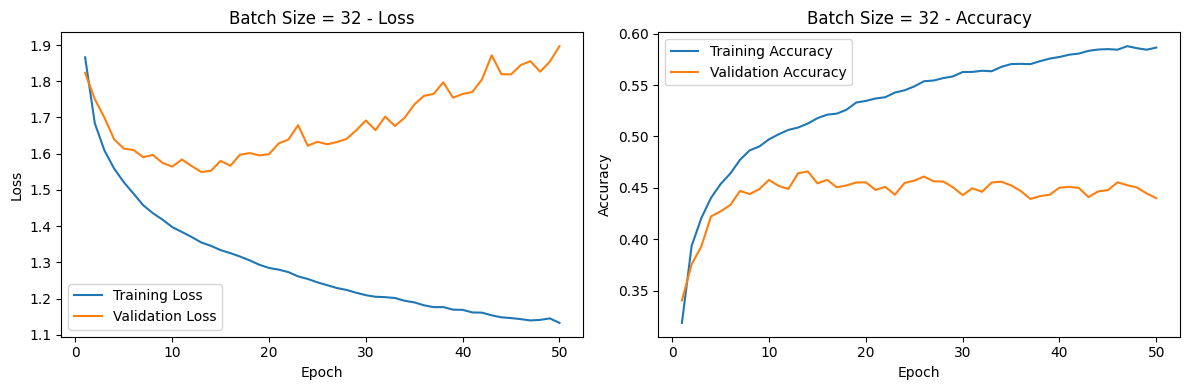

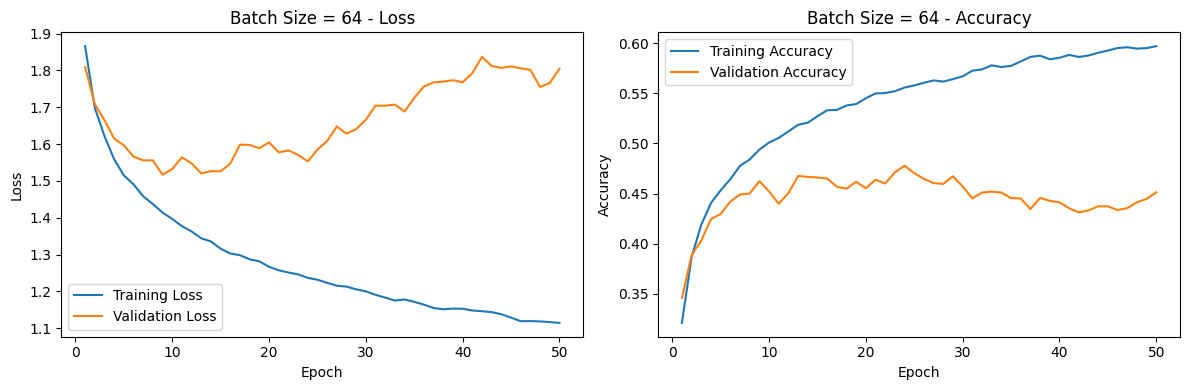

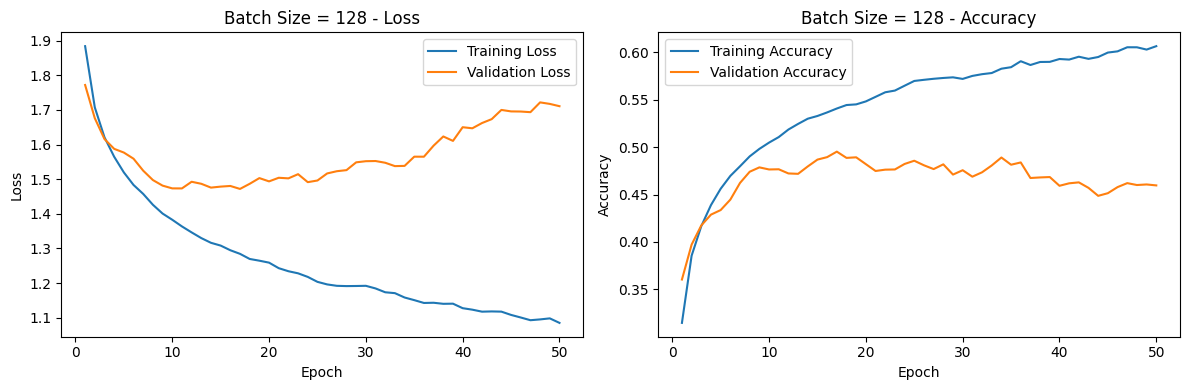

In [16]:
for bs, history in bs_histories.items():
    plot_learning_curves(history, f"Batch Size = {bs}")

### Conclusion

Within the executed `learning_rate = 0.001` branch, batch size `128` produced the strongest result: **49.52%** best validation accuracy and **1.4720** minimum validation loss. The best validation accuracies for batch sizes 16, 32, and 64 were **45.48%**, **46.60%**, and **47.78%**, respectively.

All four settings showed late overfitting under the 50-epoch budget, especially the smaller batches. Batch size `128` also required the fewest updates per epoch and had the best validation metrics in this comparison.

Therefore, batch size `128` was selected for the following experiments.

In [17]:
SELECTED_BATCH_SIZE = 128

### Optimizer

Adam and SGD are compared using reasonable learning rates for each optimizer while retaining the selected architecture and batch size.

#### Rationale

Adam is expected to converge faster and achieve stronger validation performance because it adaptively adjusts parameter updates during training.

SGD may learn more slowly and may be more sensitive to the selected learning rate.

In [18]:
optimizers = {
    "adam": SELECTED_LEARNING_RATE,
    "sgd": 0.01
}

opt_histories = {}
opt_models = {}

In [19]:
for opt_name, lr in optimizers.items():

    model = build_dense_model(
        selected_model_name,
        selected_architecture,
        learning_rate=lr,
        optimizer_name=opt_name
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=SELECTED_BATCH_SIZE,
        shuffle=True,
        verbose=0,
    )

    opt_histories[opt_name] = history
    opt_models[opt_name] = model

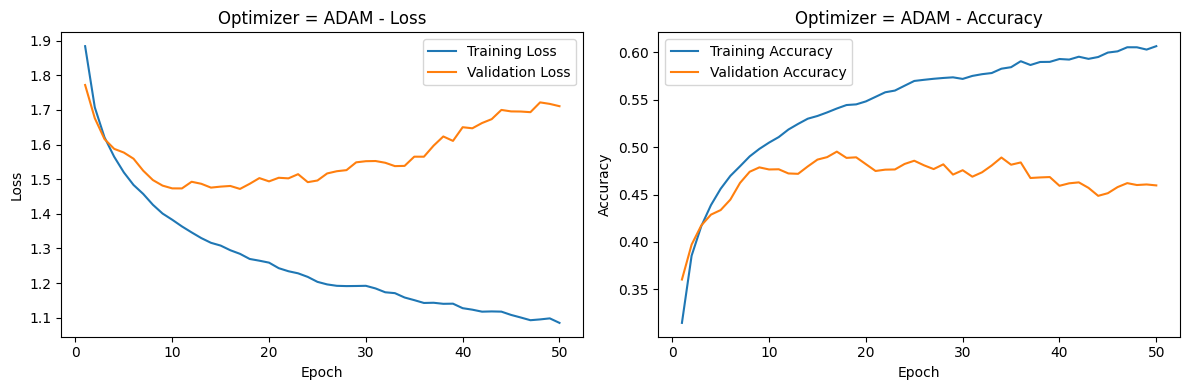

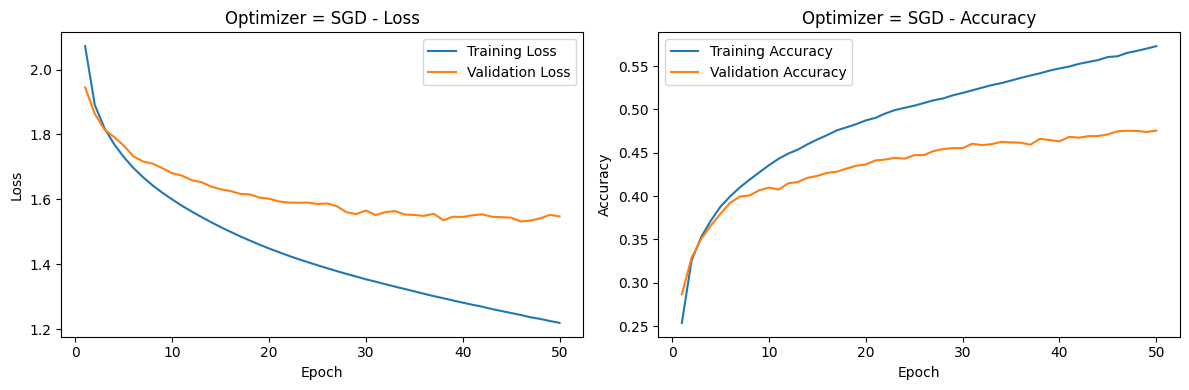

In [20]:
for opt_name, history in opt_histories.items():
    plot_learning_curves(history, f"Optimizer = {opt_name.upper()}")

### Conclusion

Adam converged faster and reached a best validation accuracy of **49.52%** with a minimum validation loss of **1.4720** at epoch 17. It then showed late overfitting under the 50-epoch budget.

SGD improved more gradually and reached **47.56%** validation accuracy at epoch 50, with a minimum validation loss of **1.5318** at epoch 46.

Adam achieved the stronger validation result and faster convergence, so it was selected as the final optimizer.

In [21]:
SELECTED_OPTIMIZER = "adam"

## Regularization & Training Stability

Dropout, Early Stopping, L2 regularization, and Batch Normalization are evaluated as controlled changes to the selected Medium network. An unregularized 80-epoch run provides the shared reference.

In [22]:
baseline_model = build_dense_model(
    selected_model_name,
    selected_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name="adam"
)

In [23]:
baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=POST_TUNING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    verbose=0,
)

### Experiment B — Dropout

**Rationale:**  
Adding Dropout is expected to reduce overfitting by preventing the model from relying too heavily on specific neurons. This may reduce training accuracy, but could improve generalization and reduce the train–validation gap.

In [24]:
dropout_model = build_dense_model(
    selected_model_name,
    selected_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name=SELECTED_OPTIMIZER,
    dropout_rate=0.3,
)


In [25]:
dropout_history = dropout_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=POST_TUNING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    verbose=0
)

### Observation

Dropout with a rate of `0.3` substantially reduced learning. Its best validation accuracy was only **34.40%**, compared with **49.52%** for the no-regularization baseline. The maximum training accuracy was **31.08%**, so the small train–validation gap reflects underfitting rather than improved generalization.

A lower dropout rate will be tested to determine whether weaker regularization provides a better balance.

#### Dropout Rate = 0.2

Since a dropout rate of `0.3` substantially reduced both training and validation performance, a lower dropout rate of `0.2` is tested.

**Rationale:**  
Reducing the dropout rate to `0.2` may provide lighter regularization, allowing the model to learn more effectively while still reducing overfitting.

In [26]:
DROPOUT_RATE = 0.2

dropout_02_model = build_dense_model(
    selected_model_name,
    selected_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name=SELECTED_OPTIMIZER,
    dropout_rate=DROPOUT_RATE,
)


In [27]:
dropout_02_history = dropout_02_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=POST_TUNING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    verbose=0
)

### Dropout Conclusion

Dropout reduced the apparent train–validation gap by suppressing training performance, not by improving validation performance.

A rate of `0.3` reached only **34.40%** best validation accuracy. Reducing the rate to `0.2` improved the result to **44.78%**, but it remained **4.74 percentage points** below the no-dropout baseline of **49.52%**.

Both rates caused underfitting in this configuration. Therefore, Dropout was not selected.

### Experiment C — Early Stopping

**Rationale:**  
Early Stopping may improve generalization by stopping training once validation loss stops improving, preventing the model from continuing to fit the training data after validation performance has plateaued.

In [28]:
early_stopping_model = build_dense_model(
    selected_model_name,
    selected_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name="adam"
)

In [29]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [30]:
EARLY_STOPPING_MAX_EPOCHS = POST_TUNING_MAX_EPOCHS

In [31]:
early_stopping_history = early_stopping_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EARLY_STOPPING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=0
)

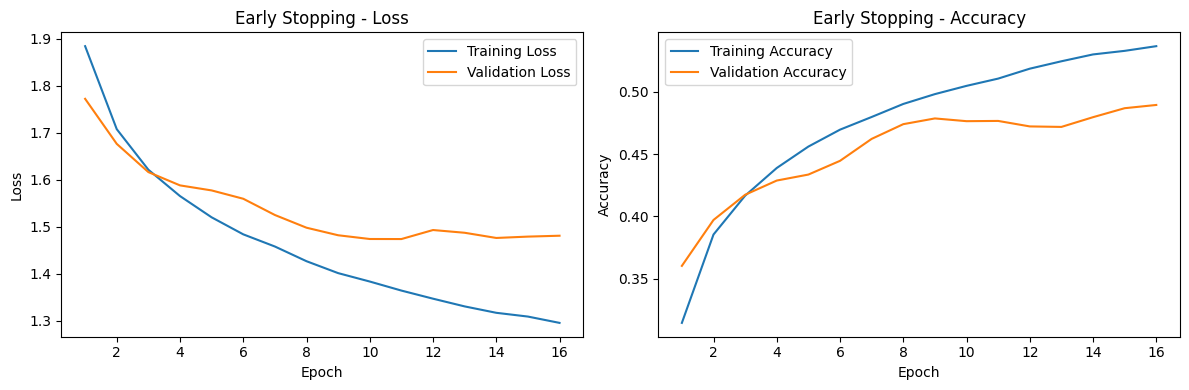

In [32]:
plot_learning_curves(
    early_stopping_history,
    "Early Stopping"
)

### Early Stopping Conclusion

Early Stopping monitored validation loss with an 80-epoch maximum and `patience=5`. Training stopped after **16 epochs** because validation loss had not improved for five consecutive epochs.

The minimum validation loss was **1.4734** at epoch 11, and the best validation accuracy observed in the history was **48.94%** at epoch 16. Because `restore_best_weights=True` monitors `val_loss`, the retained weights are from epoch 11 rather than the epoch with the highest validation accuracy.

Early Stopping therefore saved 64 potential epochs and limited continued overfitting, although its best recorded validation accuracy was slightly below the no-regularization baseline.

### Experiment D — L2 Regularization

**Rationale:**  
L2 regularization may improve generalization by discouraging excessively large weights. This is expected to reduce overfitting while allowing all neurons to remain active during training.

In [33]:
l2_rates = [0, 1e-5, 1e-4, 1e-3]

l2_histories = {}
l2_models = {}

In [34]:
for l2_rate in l2_rates:

    l2_model = build_dense_model(
        selected_model_name,
        selected_architecture,
        learning_rate=SELECTED_LEARNING_RATE,
        optimizer_name=SELECTED_OPTIMIZER,
        l2_rate=l2_rate,
    )

    history = l2_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=POST_TUNING_MAX_EPOCHS,
        batch_size=SELECTED_BATCH_SIZE,
        shuffle=True,
        verbose=0
    )

    l2_models[l2_rate] = l2_model
    l2_histories[l2_rate] = history


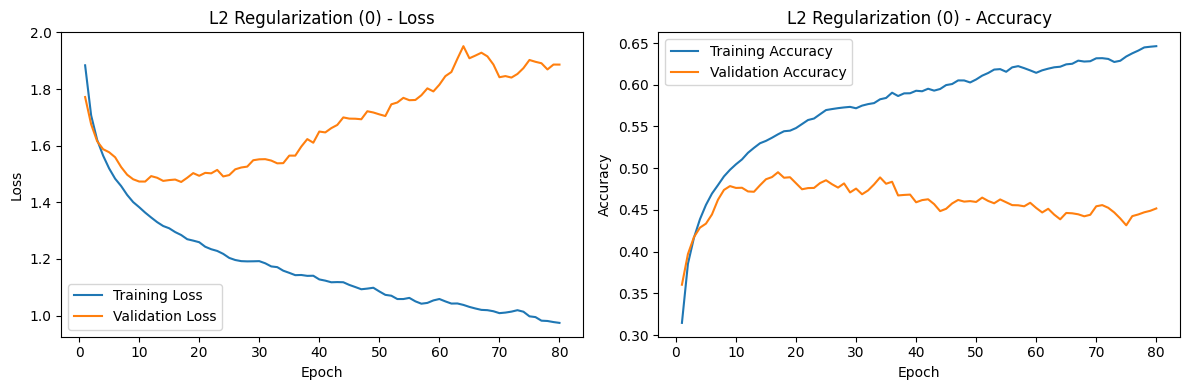

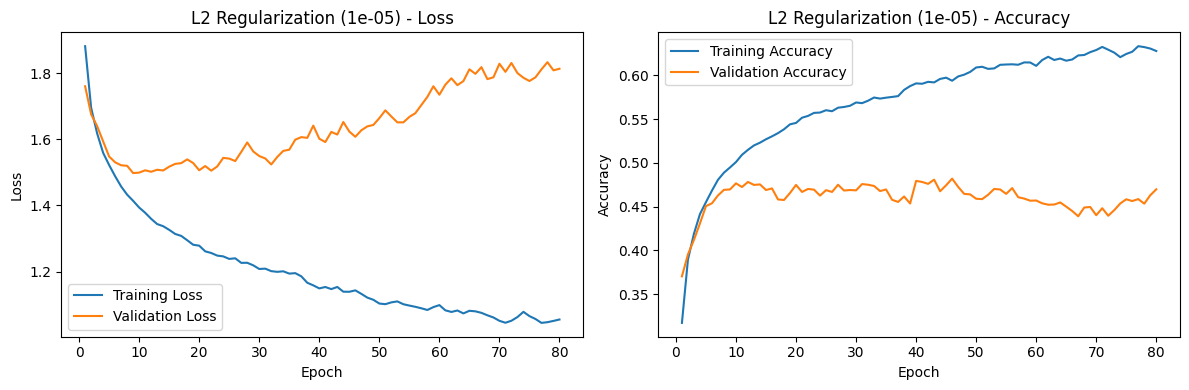

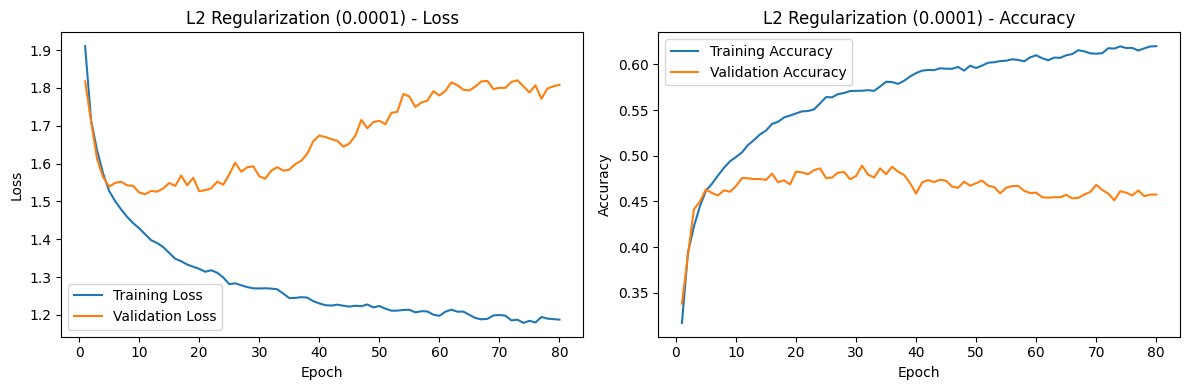

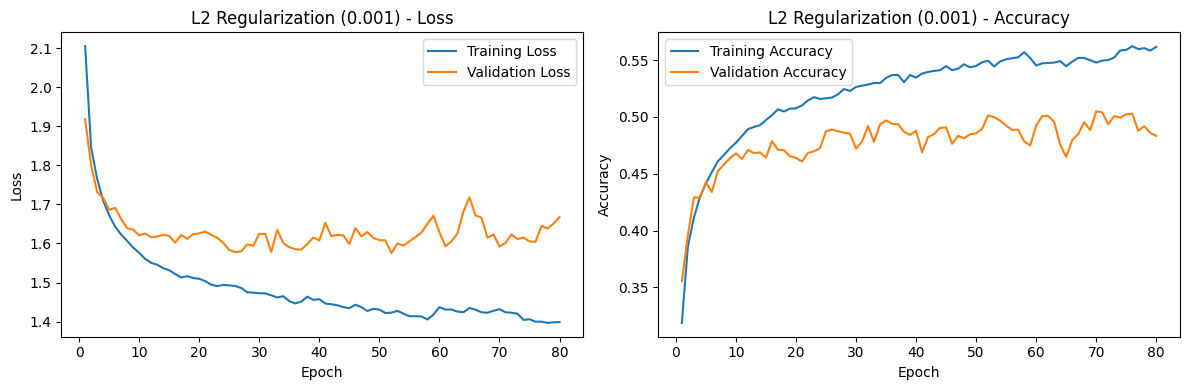

In [35]:
for l2_rate in l2_rates:
    plot_learning_curves(
        l2_histories[l2_rate],
        f"L2 Regularization ({l2_rate})"
    )

### L2 Regularization Conclusion

The L2 results were mixed. The strongest tested value, `L2 = 1e-3`, achieved the highest validation accuracy: **50.50%** at epoch 70. This was **0.98 percentage points** above the no-L2 baseline of **49.52%**.

The weaker non-zero settings reached **48.20%** (`1e-5`) and **48.92%** (`1e-4`). The no-L2 baseline still had the lowest reported validation loss, **1.4720**, while `1e-3` had a minimum of **1.5752**. Because Keras includes the regularization penalty in the loss, validation-loss values are not directly comparable across different L2 strengths in exactly the same way as validation accuracy.

Therefore, `L2 = 1e-3` produced the highest validation accuracy among the L2 settings, but it was not selected for the final model because its improvement was small, it required 70 epochs to reach the peak, and it did not provide the computation savings offered by Early Stopping.

### Regularization Conclusion

Dropout reduced both training and validation performance. In contrast, `L2 = 1e-3` produced the highest best validation accuracy in this stage (**50.50%**), while the no-regularization baseline reached **49.52%**.

Early Stopping stopped after 16 of 80 epochs and restored the epoch-11 weights, making it the most efficient guardrail against unnecessary training. Its best recorded validation accuracy was **48.94%**, so it saved computation rather than improving the peak score.

Therefore, `L2 = 1e-3` was the accuracy-oriented option, while Early Stopping was the efficiency and overfitting-control option. Early Stopping was selected for the final model because it achieved comparable validation performance with much less training.

### Regularization Experiments — Conclusion

The regularization experiments showed that the effect depended strongly on the technique and strength.

Dropout caused underfitting and was rejected. `L2 = 1e-3` improved the best validation accuracy from **49.52%** to **50.50%**, although it required 70 epochs to reach that peak. Early Stopping stopped after 16 epochs and prevented the large late-overfitting region, but it did not increase the peak validation accuracy.

Batch Normalization is assessed separately in the preceding experiment. L2 was the accuracy-oriented candidate, while Early Stopping was the compute-control candidate.

Early Stopping was selected for the final model because it stopped after 16 epochs, restored the best validation-loss weights, and avoided the severe late-overfitting region without adding architectural complexity. Dropout and L2 were excluded from the final configuration.

### Batch Normalization

Batch Normalization is evaluated separately as a training-stability intervention on both the selected Medium network and the Deep architecture.

In [36]:
bn_model = build_dense_model(
    selected_model_name,
    selected_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name=SELECTED_OPTIMIZER,
    use_batchnorm=True,
)


In [37]:
bn_history = bn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=POST_TUNING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    verbose=0
)

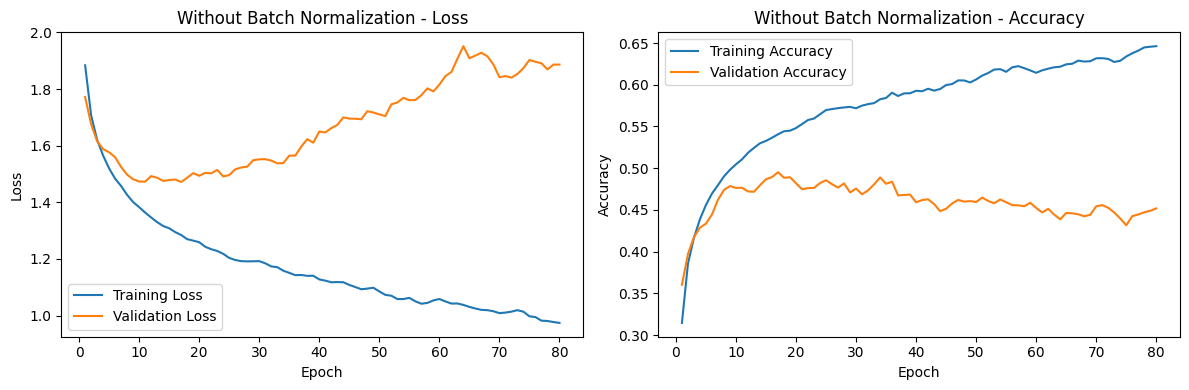

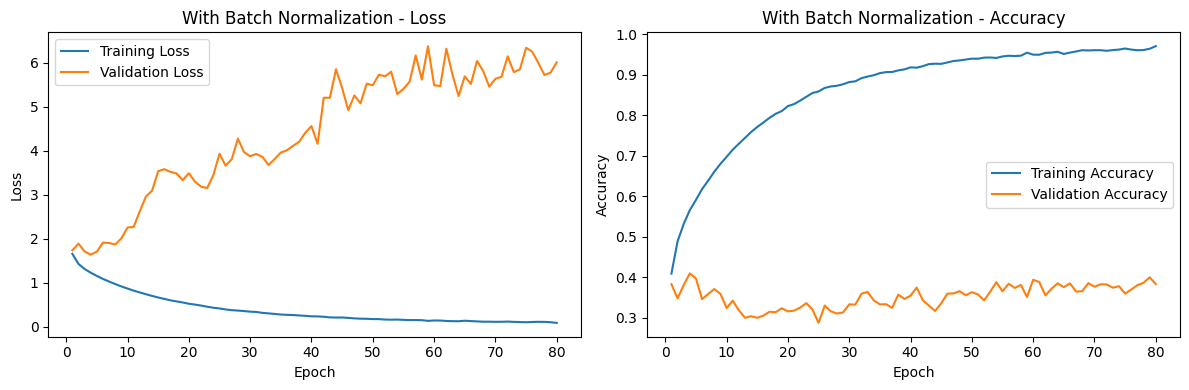

In [38]:
plot_learning_curves(baseline_history, "Without Batch Normalization")
plot_learning_curves(bn_history, "With Batch Normalization")

#### Batch Normalization on a Deeper Network

In the selected model, Batch Normalization changed the training behavior but did not improve validation performance.

To investigate whether its effect becomes more noticeable as network depth increases, the same comparison is repeated using the original Deep architecture.

The architecture depth is the main factor being changed, while the training settings are kept consistent.

In [39]:
deep_architecture = architectures["Deep"]

In [40]:
deep_no_bn_model = build_dense_model(
    "Deep_No_BN",
    deep_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name=SELECTED_OPTIMIZER
)

In [41]:
deep_no_bn_history = deep_no_bn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=POST_TUNING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    verbose=0
)

In [42]:
deep_bn_model = build_dense_model(
    "Deep_With_BN",
    deep_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name=SELECTED_OPTIMIZER,
    use_batchnorm=True,
)


In [43]:
deep_bn_history = deep_bn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=POST_TUNING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    verbose=0
)

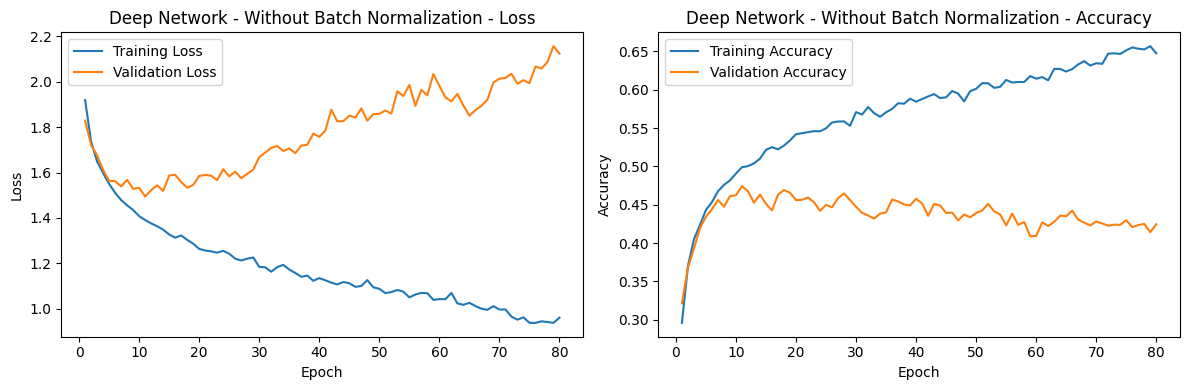

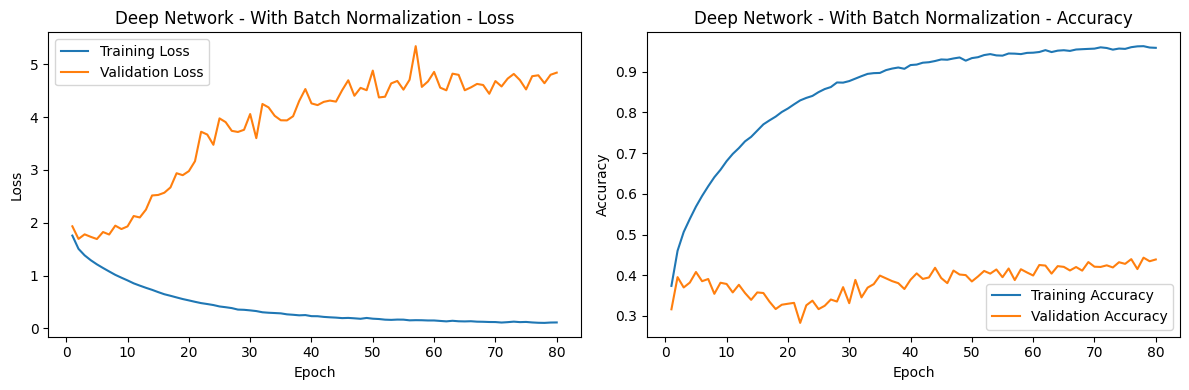

In [44]:
plot_learning_curves(
    deep_no_bn_history,
    "Deep Network - Without Batch Normalization"
)

plot_learning_curves(
    deep_bn_history,
    "Deep Network - With Batch Normalization"
)

### Batch Normalization — Conclusion

Batch Normalization noticeably accelerated fitting on the training set, but it substantially worsened generalization.

For the selected Medium network, Batch Normalization raised best training accuracy to **97.12%** but reduced best validation accuracy to **40.96%**, compared with **64.62%** best training and **49.52%** best validation without it. The final validation loss with Batch Normalization rose to **6.0110**.

The Deep network showed the same pattern: Batch Normalization raised best training accuracy from **65.67%** to **96.28%**, while best validation accuracy fell from **47.42%** to **44.32%** and validation loss increased sharply.

Therefore, Batch Normalization improved optimization but produced severe overfitting in both architectures. It is not supported for the current Dense model.

## Ablation Study

Early Stopping is isolated by comparing two otherwise identical models with the same 80-epoch ceiling. Model A monitors validation loss with `patience=5`; Model B trains for the full budget.

In [45]:
ablation_model_a = build_dense_model(
    selected_model_name,
    selected_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name=SELECTED_OPTIMIZER
)

In [46]:
ablation_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [47]:
ablation_history_a = ablation_model_a.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=POST_TUNING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    callbacks=[ablation_early_stopping],
    verbose=0
)

In [48]:
ablation_model_b = build_dense_model(
    selected_model_name,
    selected_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name=SELECTED_OPTIMIZER
)

In [49]:
ablation_history_b = ablation_model_b.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=POST_TUNING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    verbose=0
)

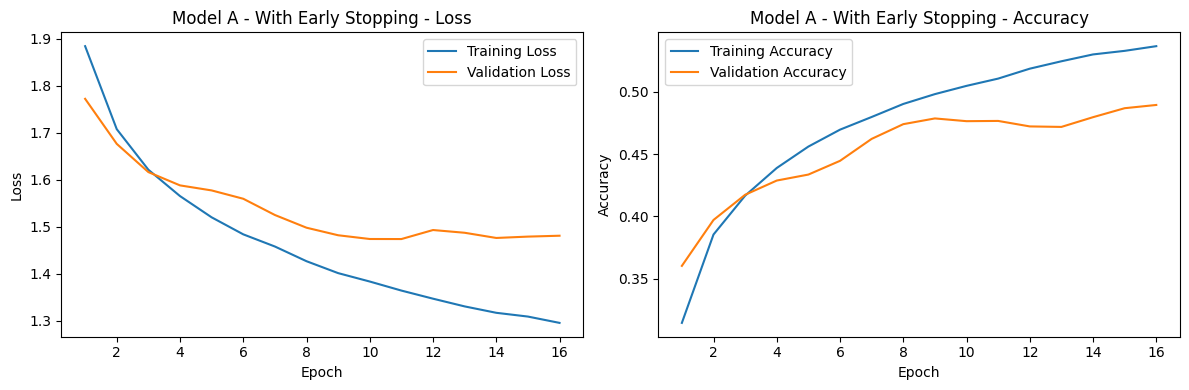

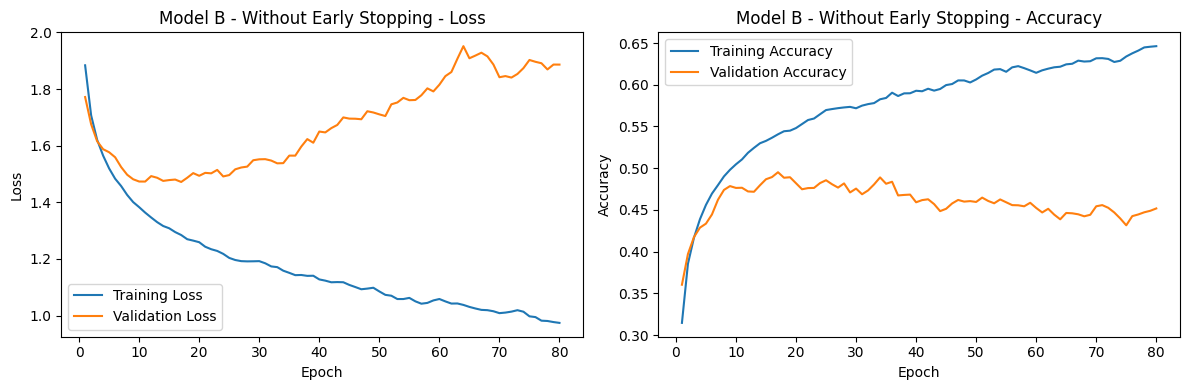

In [50]:
plot_learning_curves(
    ablation_history_a,
    "Model A - With Early Stopping"
)

plot_learning_curves(
    ablation_history_b,
    "Model B - Without Early Stopping"
)

In [51]:
print("Model A - With Early Stopping")
print("Epochs trained:", len(ablation_history_a.history["loss"]))
print("Best Val Accuracy:", max(ablation_history_a.history["val_accuracy"]))
print("Min Val Loss:", min(ablation_history_a.history["val_loss"]))

print()

print("Model B - Without Early Stopping")
print("Epochs trained:", len(ablation_history_b.history["loss"]))
print("Best Val Accuracy:", max(ablation_history_b.history["val_accuracy"]))
print("Min Val Loss:", min(ablation_history_b.history["val_loss"]))

Model A - With Early Stopping
Epochs trained: 16
Best Val Accuracy: 0.4893999993801117
Min Val Loss: 1.4734070301055908

Model B - Without Early Stopping
Epochs trained: 80
Best Val Accuracy: 0.4952000081539154
Min Val Loss: 1.4719693660736084


### Ablation Experiment — Conclusion

Both ablation models had the same 80-epoch maximum. Model A used Early Stopping and stopped after **16 epochs**; Model B trained for all **80 epochs**.

Model A reached **48.94%** best validation accuracy and **1.4734** minimum validation loss. Model B reached **49.52%** and **1.4720**, respectively, but its validation accuracy finished at 45.18% while training accuracy continued to 64.62%, showing substantial late overfitting.

Early Stopping saved **64 epochs** at a cost of only **0.58 percentage points** in the best validation accuracy observed in the history. It is useful as an efficiency and overfitting guardrail, not as an accuracy improvement.

## Final Model

The final configuration is selected from the completed experiments by balancing validation performance, convergence speed, computational cost, and overfitting control.

### Selected Configuration

- **Architecture:** Medium network with three 128-unit ReLU hidden layers
- **Optimizer:** Adam
- **Learning rate:** `0.001`
- **Batch size:** `128`
- **Maximum epochs:** `80`
- **Early Stopping:** monitor validation loss, `patience=5`, restore best weights
- **Dropout / L2 / Batch Normalization:** not included

This is a practical selection rather than the single highest validation score: `0.0001` and `L2=1e-3` produced higher peaks but required substantially longer training, while Early Stopping curtailed the late-overfitting region.

In [52]:
final_model = build_dense_model(
    "Final_Model",
    selected_architecture,
    learning_rate=SELECTED_LEARNING_RATE,
    optimizer_name=SELECTED_OPTIMIZER
)

In [53]:
final_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [54]:
final_history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=POST_TUNING_MAX_EPOCHS,
    batch_size=SELECTED_BATCH_SIZE,
    shuffle=True,
    callbacks=[final_early_stopping],
    verbose=0
)

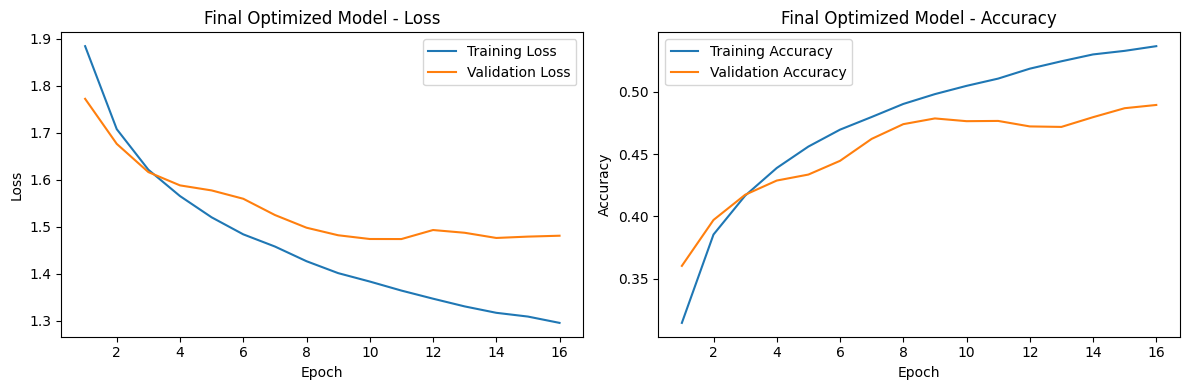

In [55]:
plot_learning_curves(
    final_history,
    "Final Optimized Model"
)

In [56]:
final_model.summary()

Model: "final_model_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282,976 (4.89 MB)

 Trainable params: 427,658 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 855,318 (3.26 MB)

In [57]:
trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in final_model.trainable_weights
)

print("Trainable parameters:", trainable_params)

Trainable parameters: 427658


The final optimized model contains **427,658 trainable parameters**.

The larger total parameter count shown after training includes additional optimizer state variables created by Adam. These optimizer parameters are not part of the model's trainable weights.

## Final Test Evaluation

Only after the architecture and training configuration are fixed is the final model evaluated on the previously untouched CIFAR-10 test set.

In [58]:
test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 1.4420753717422485
Test Accuracy: 0.4925999939441681


In [59]:
y_test_true = y_test.reshape(-1)

y_test_prob = final_model.predict(
    X_test,
    verbose=0
)

y_test_pred = np.argmax(y_test_prob, axis=1)

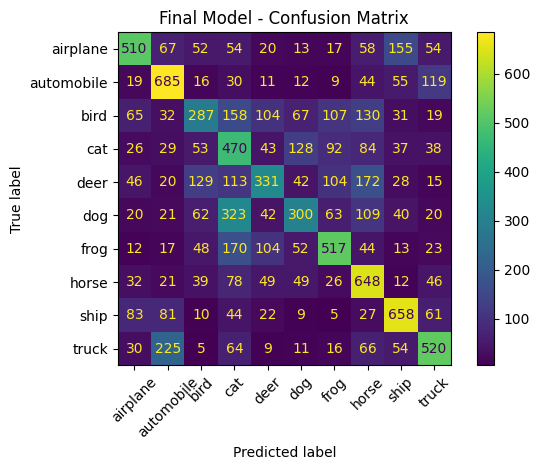

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_true,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45
)

plt.title("Final Model - Confusion Matrix")
plt.tight_layout()
plt.show()

In [61]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.6050    0.5100    0.5534      1000
  automobile     0.5718    0.6850    0.6233      1000
        bird     0.4094    0.2870    0.3374      1000
         cat     0.3125    0.4700    0.3754      1000
        deer     0.4503    0.3310    0.3816      1000
         dog     0.4392    0.3000    0.3565      1000
        frog     0.5408    0.5170    0.5286      1000
       horse     0.4689    0.6480    0.5441      1000
        ship     0.6076    0.6580    0.6318      1000
       truck     0.5683    0.5200    0.5431      1000

    accuracy                         0.4926     10000
   macro avg     0.4974    0.4926    0.4875     10000
weighted avg     0.4974    0.4926    0.4875     10000



### Final Test Evaluation — Summary

The final `0.001` + Early Stopping model achieved a **test accuracy of 49.26%** and a **test loss of 1.4421** on the unseen Test Set.

The Macro F1-score was **0.4875**, showing that performance varied across the ten CIFAR-10 classes.

The test accuracy was close to the best validation accuracy recorded during this model's training history (**48.94%**), a difference of **0.32 percentage points**.

The confusion matrix also shows clear differences in class-level performance, which are examined in the error analysis. No additional tuning was performed after viewing the Test Set.

## Error Analysis

Class-level metrics, dominant confusion pairs, and representative mistakes show where aggregate accuracy hides systematic weaknesses.

In [62]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test_true,
    y_test_pred
)

class_performance = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})

class_performance = class_performance.sort_values(
    "F1-score",
    ascending=False
)

display(class_performance)

,Class,Precision,Recall,F1-score,Support
8,ship,0.607572,0.658,0.631781,1000
1,automobile,0.571786,0.685,0.623294,1000
0,airplane,0.604982,0.510,0.553445,1000
7,horse,0.468886,0.648,0.544081,1000
9,truck,0.568306,0.520,0.543081,1000
6,frog,0.540795,0.517,0.528630,1000
4,deer,0.450340,0.331,0.381556,1000
3,cat,0.312500,0.470,0.375399,1000
5,dog,0.439239,0.300,0.356506,1000
2,bird,0.409415,0.287,0.337449,1000


In [63]:
confusion_pairs = []

for true_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):
        if true_idx != pred_idx:
            confusion_pairs.append({
                "True Class": class_names[true_idx],
                "Predicted As": class_names[pred_idx],
                "Count": cm[true_idx, pred_idx]
            })

confusion_pairs = pd.DataFrame(confusion_pairs)

confusion_pairs = confusion_pairs.sort_values(
    "Count",
    ascending=False
).head(10)

display(confusion_pairs)

,True Class,Predicted As,Count
48,dog,cat,323
82,truck,automobile,225
42,deer,horse,172
57,frog,cat,170
20,bird,cat,158
7,airplane,ship,155
24,bird,horse,130
38,deer,bird,129
31,cat,dog,128
17,automobile,truck,119


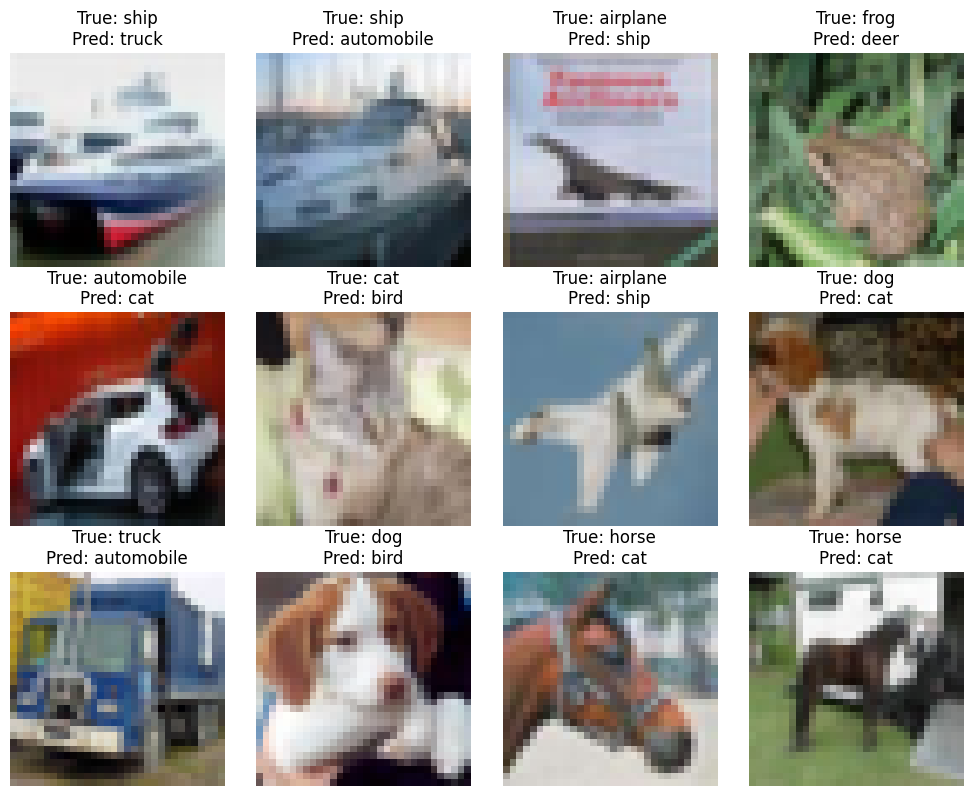

In [64]:
X_test_images = X_test.reshape(-1, 32, 32, 3)
misclassified_indices = np.where(
    y_test_true != y_test_pred
)[0]

plt.figure(figsize=(10, 8))

for i, idx in enumerate(misclassified_indices[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test_images[idx])

    plt.title(
        f"True: {class_names[y_test_true[idx]]}\n"
        f"Pred: {class_names[y_test_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Error Analysis — Conclusion

The evaluated model showed noticeable differences across CIFAR-10 classes. Ship and automobile were strongest by F1-score (**0.6318** and **0.6233**), while bird was weakest (**0.3374**), followed by dog (**0.3565**) and cat (**0.3754**).

The largest recurring errors were dog → cat (**323**), truck → automobile (**225**), deer → horse (**172**), frog → cat (**170**), bird → cat (**158**), and airplane → ship (**155**). The reverse automobile → truck error also occurred 119 times. Many of these classes share similar visual characteristics, which makes them difficult to distinguish at low resolution.

The misclassified examples also show that the low resolution of CIFAR-10 images can make object boundaries and visual details difficult to identify.

A major limitation is that the Dense network receives each image as a flattened vector of 3,072 values. This removes the explicit two-dimensional spatial structure of the image, making it harder for the model to learn local visual patterns such as shapes, edges, and object parts.

A convolutional architecture would likely be better suited to these spatial patterns, but the current experiment intentionally uses a Dense neural network.

## Pixel Shift Sensitivity

A controlled horizontal-shift test probes whether the flattened Dense representation is robust when the same object appears at a different pixel location.

In [65]:
shift_pixels = 2

X_test_shifted = np.zeros_like(X_test_images)

X_test_shifted[:, :, shift_pixels:, :] = (
    X_test_images[:, :, :-shift_pixels, :]
)

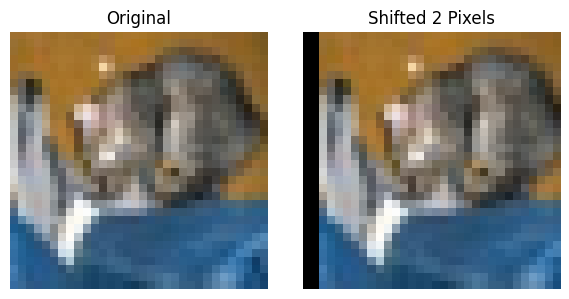

In [66]:
sample_idx = 0

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(X_test_images[sample_idx])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_test_shifted[sample_idx])
plt.title("Shifted 2 Pixels")
plt.axis("off")

plt.tight_layout()
plt.show()

In [67]:
def shift_images_horizontally(images, shift_pixels):
    """Shift a batch of images right by `shift_pixels`, filling the vacated
    columns with zeros. Labels are unaffected — only pixel position changes."""
    shifted = np.zeros_like(images)
    if shift_pixels > 0:
        shifted[:, :, shift_pixels:, :] = images[:, :, :-shift_pixels, :]
    else:
        shifted = images.copy()
    return shifted

shift_distances = [1, 2, 4, 8]
shift_results = {0: test_accuracy}  # 0-pixel shift = the original, already-evaluated test accuracy

for distance in shift_distances:
    shifted_images = shift_images_horizontally(X_test_images, distance)
    shifted_flat = shifted_images.reshape(-1, 3072)
    _, shifted_acc = final_model.evaluate(shifted_flat, y_test, verbose=0)
    shift_results[distance] = shifted_acc
    print(f"Shift = {distance:2d}px -> Test Accuracy = {shifted_acc:.4f}")


Shift =  1px -> Test Accuracy = 0.4570
Shift =  2px -> Test Accuracy = 0.3892
Shift =  4px -> Test Accuracy = 0.2644
Shift =  8px -> Test Accuracy = 0.2083


,Shift (pixels),Test Accuracy
0,0,0.4926
1,1,0.4570
2,2,0.3892
3,4,0.2644
4,8,0.2083


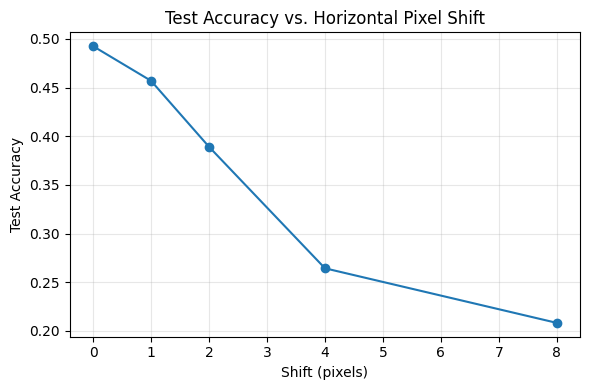

In [68]:
shift_summary_df = pd.DataFrame({
    "Shift (pixels)": list(shift_results.keys()),
    "Test Accuracy": list(shift_results.values()),
}).sort_values("Shift (pixels)").reset_index(drop=True)
display(shift_summary_df.style.format({"Test Accuracy": "{:.4f}"}))

plt.figure(figsize=(6, 4))
plt.plot(shift_summary_df["Shift (pixels)"], shift_summary_df["Test Accuracy"], marker="o")
plt.title("Test Accuracy vs. Horizontal Pixel Shift")
plt.xlabel("Shift (pixels)")
plt.ylabel("Test Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Pixel Shift Sensitivity — Conclusion

Test accuracy fell from **49.26%** with no shift to **20.83%** after an 8-pixel horizontal shift—a drop of **28.43 percentage points**—even though every image retained the same object and true label. Even a 2-pixel shift reduced accuracy to **38.92%**.

This directly demonstrates the limitation discussed in the preceding experiment: because the image is flattened into 3,072 independent input positions, the network's learned weights are tied to *where* a pattern appears rather than *what* the pattern is. A translation-invariant architecture (a CNN, via weight sharing and pooling) would be expected to show far less degradation under the same shift.


### Experiment Summary

The table below consolidates the major experimental branches using their recorded best validation accuracies.

In [69]:
experiment_tracking = pd.DataFrame([
    # Note: the Part 3 baseline_model was only compiled/summarized, never
    # fit(), so there is no separate "Baseline" history to report here.
    # The Shallow architecture below (Part 5) is the equivalent trained model.
    {
        "Experiment": "Shallow",
        "Architecture": "Shallow",
        "LR": LEARNING_RATE,
        "Batch": BATCH_SIZE,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "No",
        "Early Stop": "No",
        "Best Val Acc.": max(histories["Shallow"]["val_accuracy"])
    },

    {
        "Experiment": "Medium",
        "Architecture": "Medium",
        "LR": LEARNING_RATE,
        "Batch": BATCH_SIZE,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "No",
        "Early Stop": "No",
        "Best Val Acc.": max(histories["Medium"]["val_accuracy"])
    },

    {
        "Experiment": "Deep",
        "Architecture": "Deep",
        "LR": LEARNING_RATE,
        "Batch": BATCH_SIZE,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "No",
        "Early Stop": "No",
        "Best Val Acc.": max(histories["Deep"]["val_accuracy"])
    },

    {
        "Experiment": "LR Tuning",
        "Architecture": selected_model_name,
        "LR": SELECTED_LEARNING_RATE,
        "Batch": BATCH_SIZE,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "No",
        "Early Stop": "No",
        "Best Val Acc.": max(
            lr_histories[SELECTED_LEARNING_RATE].history["val_accuracy"]
        )
    },

    {
        "Experiment": "Batch Tuning",
        "Architecture": selected_model_name,
        "LR": SELECTED_LEARNING_RATE,
        "Batch": SELECTED_BATCH_SIZE,
        "Optimizer": "Adam",
        "Dropout": "No",
        "BatchNorm": "No",
        "Early Stop": "No",
        "Best Val Acc.": max(
            bs_histories[SELECTED_BATCH_SIZE].history["val_accuracy"]
        )
    },

    {
        "Experiment": "Optimizer",
        "Architecture": selected_model_name,
        "LR": SELECTED_LEARNING_RATE,
        "Batch": SELECTED_BATCH_SIZE,
        "Optimizer": SELECTED_OPTIMIZER,
        "Dropout": "No",
        "BatchNorm": "No",
        "Early Stop": "No",
        "Best Val Acc.": max(
            opt_histories[SELECTED_OPTIMIZER].history["val_accuracy"]
        )
    },

    {
        "Experiment": "Dropout",
        "Architecture": selected_model_name,
        "LR": SELECTED_LEARNING_RATE,
        "Batch": SELECTED_BATCH_SIZE,
        "Optimizer": SELECTED_OPTIMIZER,
        "Dropout": "0.2",
        "BatchNorm": "No",
        "Early Stop": "No",
        "Best Val Acc.": max(
            dropout_02_history.history["val_accuracy"]
        )
    },

    {
        # Best of the non-zero L2 rates actually tested (1e-5, 1e-4, 1e-3),
        # not the L2=0 control, which is already represented by the
        # Regularization Baseline (Part 12, Experiment A).
        "Experiment": "L2 (best rate)",
        "Architecture": selected_model_name,
        "LR": SELECTED_LEARNING_RATE,
        "Batch": SELECTED_BATCH_SIZE,
        "Optimizer": SELECTED_OPTIMIZER,
        "Dropout": "No",
        "BatchNorm": "No",
        "Early Stop": "No",
        "Best Val Acc.": max(
            max(l2_histories[rate].history["val_accuracy"])
            for rate in l2_rates if rate != 0
        )
    },

    {
        "Experiment": "Early Stopping",
        "Architecture": selected_model_name,
        "LR": SELECTED_LEARNING_RATE,
        "Batch": SELECTED_BATCH_SIZE,
        "Optimizer": SELECTED_OPTIMIZER,
        "Dropout": "No",
        "BatchNorm": "No",
        "Early Stop": "Yes",
        "Best Val Acc.": max(
            early_stopping_history.history["val_accuracy"]
        )
    },

    {
        "Experiment": "BatchNorm",
        "Architecture": selected_model_name,
        "LR": SELECTED_LEARNING_RATE,
        "Batch": SELECTED_BATCH_SIZE,
        "Optimizer": SELECTED_OPTIMIZER,
        "Dropout": "No",
        "BatchNorm": "Yes",
        "Early Stop": "No",
        "Best Val Acc.": max(
            bn_history.history["val_accuracy"]
        )
    },

    {
        "Experiment": "Final Model",
        "Architecture": selected_model_name,
        "LR": SELECTED_LEARNING_RATE,
        "Batch": SELECTED_BATCH_SIZE,
        "Optimizer": SELECTED_OPTIMIZER,
        "Dropout": "No",
        "BatchNorm": "No",
        "Early Stop": "Yes",
        "Best Val Acc.": max(
            final_history.history["val_accuracy"]
        )
    }
])

display(
    experiment_tracking.style.format({
        "LR": "{:.5f}",
        "Best Val Acc.": "{:.4f}"
    })
)

,Experiment,Architecture,LR,Batch,Optimizer,Dropout,BatchNorm,Early Stop,Best Val Acc.
0,Shallow,Shallow,0.00100,128,Adam,No,No,No,0.4696
1,Medium,Medium,0.00100,128,Adam,No,No,No,0.4952
2,Deep,Deep,0.00100,128,Adam,No,No,No,0.4742
3,LR Tuning,Medium,0.00100,128,Adam,No,No,No,0.4952
4,Batch Tuning,Medium,0.00100,128,Adam,No,No,No,0.4952
5,Optimizer,Medium,0.00100,128,adam,No,No,No,0.4952
6,Dropout,Medium,0.00100,128,adam,0.2,No,No,0.4478
7,L2 (best rate),Medium,0.00100,128,adam,No,No,No,0.5050
8,Early Stopping,Medium,0.00100,128,adam,No,No,Yes,0.4894
9,BatchNorm,Medium,0.00100,128,adam,No,Yes,No,0.4096


## Key Findings and CNN Motivation

- **Depth alone did not solve the task.** Shallow, Medium, and Deep networks reached 46.96%, 49.52%, and 47.42% best validation accuracy. The Deep network overfit most strongly.
- **Optimization involved an accuracy–efficiency tradeoff.** A learning rate of `0.0001` reached 51.80% validation accuracy at the end of 50 epochs; `0.001` reached 49.52% by epoch 17 and was retained for faster convergence. Batch size 128 was strongest in its experiment, and Adam outperformed SGD (49.52% vs. 47.56%).
- **Regularization was technique-dependent.** Dropout underfit. `L2=1e-3` peaked at 50.50% but only at epoch 70. Early Stopping achieved 48.94% in 16 epochs and was selected as the practical guardrail. Batch Normalization accelerated training but reduced Medium-network validation accuracy to 40.96%.
- **Final held-out performance was 49.26% accuracy, 1.4421 loss, and 0.4875 macro F1.** The strongest classes by F1 were ship and automobile; bird was weakest. Dominant confusions included dog→cat, truck→automobile, and deer→horse.
- **Translation sensitivity exposed the representation limit.** Accuracy fell from 49.26% with no shift to 38.92% after 2 pixels and 20.83% after 8 pixels.

Flattening preserves pixel values but removes explicit two-dimensional locality. Every Dense weight is tied to an absolute input position, so the model must relearn similar patterns at different locations and cannot naturally exploit nearby pixels, shared edges, textures, or object parts. The structured class errors and shift degradation show that further scalar tuning cannot fully repair this inductive-bias mismatch.

Convolutional neural networks are therefore the logical next step: local receptive fields preserve neighborhood structure, shared filters detect the same feature across positions, and pooling can improve tolerance to small translations.